Shape: (3456, 5184, 3)  dtype: float64


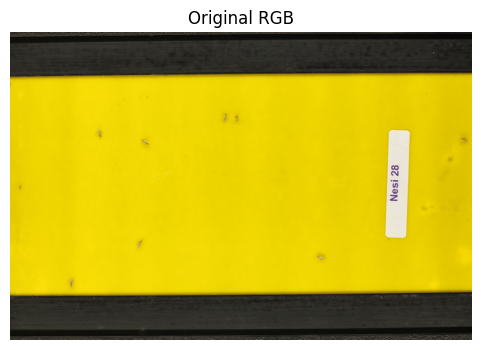

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image, values in [0, 1]
img_pil = Image.open("1095.jpg").convert("RGB")
img_rgb = np.asarray(img_pil, dtype=np.float64) / 255.0

print("Shape:", img_rgb.shape, " dtype:", img_rgb.dtype)

plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title("Original RGB")
plt.axis("off")
plt.show()

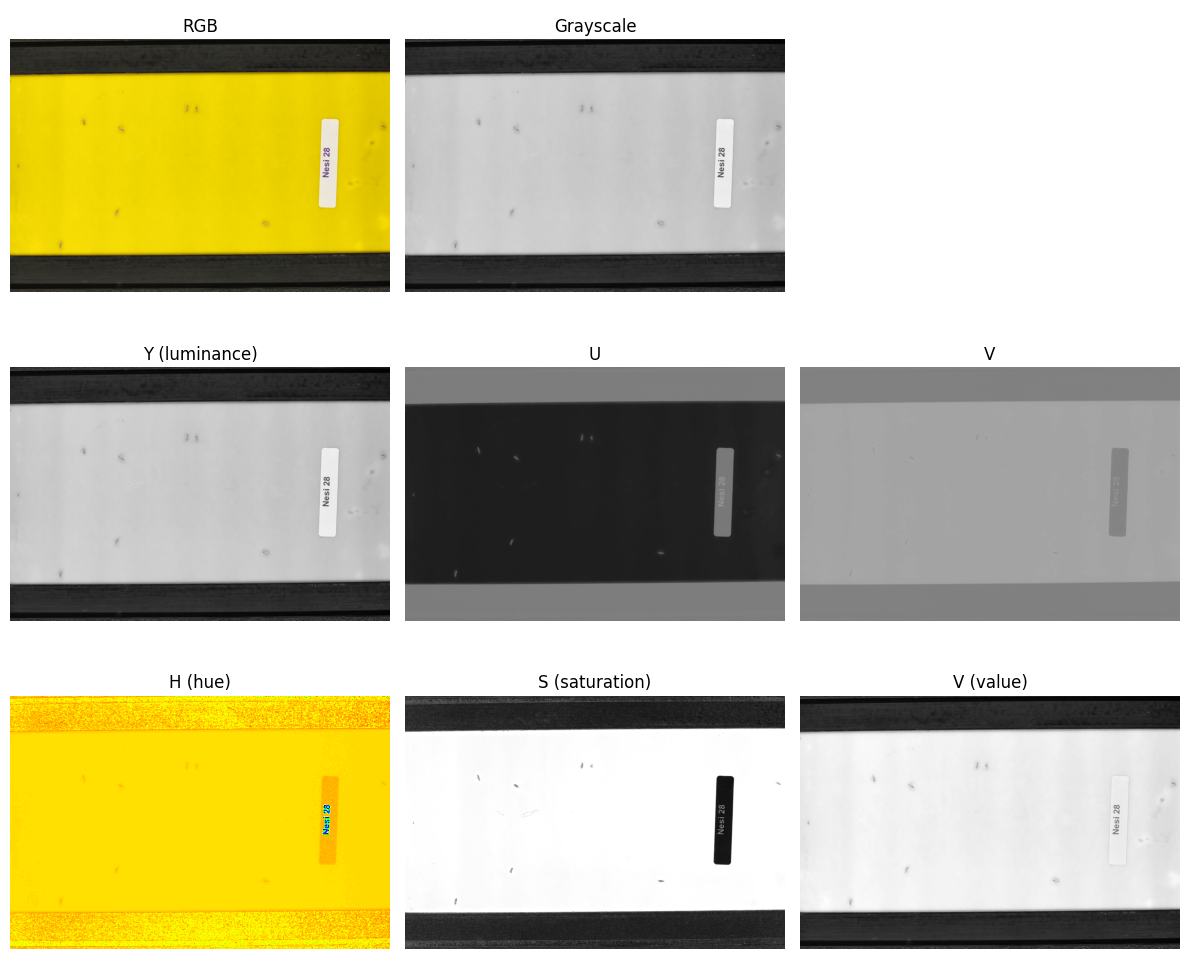

In [2]:
# Grayscale, YUV, HSV by hand
H, W, _ = img_rgb.shape
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

gray = 0.299 * R + 0.587 * G + 0.114 * B

Y = gray.copy()
U = -0.14713 * R - 0.28886 * G + 0.436 * B
V = 0.615 * R - 0.51499 * G - 0.10001 * B

img_hsv = np.zeros_like(img_rgb)
for i in range(H):
    for j in range(W):
        r, g, b = R[i, j], G[i, j], B[i, j]
        cmax = max(r, g, b)
        cmin = min(r, g, b)
        diff = cmax - cmin

        v = cmax

        s = 0.0 if cmax == 0 else diff / cmax

        if diff == 0:
            h = 0.0
        elif cmax == r:
            h = 60.0 * (((g - b) / diff) % 6)
        elif cmax == g:
            h = 60.0 * (((b - r) / diff) + 2)
        else:
            h = 60.0 * (((r - g) / diff) + 4)

        img_hsv[i, j] = [h / 360.0, s, v]

hsv_h = img_hsv[:, :, 0]
hsv_s = img_hsv[:, :, 1]
hsv_v = img_hsv[:, :, 2]

# Compare channels
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

axes[0, 0].imshow(img_rgb);           axes[0, 0].set_title("RGB")
axes[0, 1].imshow(gray, cmap="gray"); axes[0, 1].set_title("Grayscale")
axes[0, 2].axis("off")

axes[1, 0].imshow(Y, cmap="gray");                         axes[1, 0].set_title("Y (luminance)")
axes[1, 1].imshow(U, cmap="gray", vmin=-0.5, vmax=0.5);    axes[1, 1].set_title("U")
axes[1, 2].imshow(V, cmap="gray", vmin=-0.5, vmax=0.5);    axes[1, 2].set_title("V")

axes[2, 0].imshow(hsv_h, cmap="hsv");  axes[2, 0].set_title("H (hue)")
axes[2, 1].imshow(hsv_s, cmap="gray"); axes[2, 1].set_title("S (saturation)")
axes[2, 2].imshow(hsv_v, cmap="gray"); axes[2, 2].set_title("V (value)")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

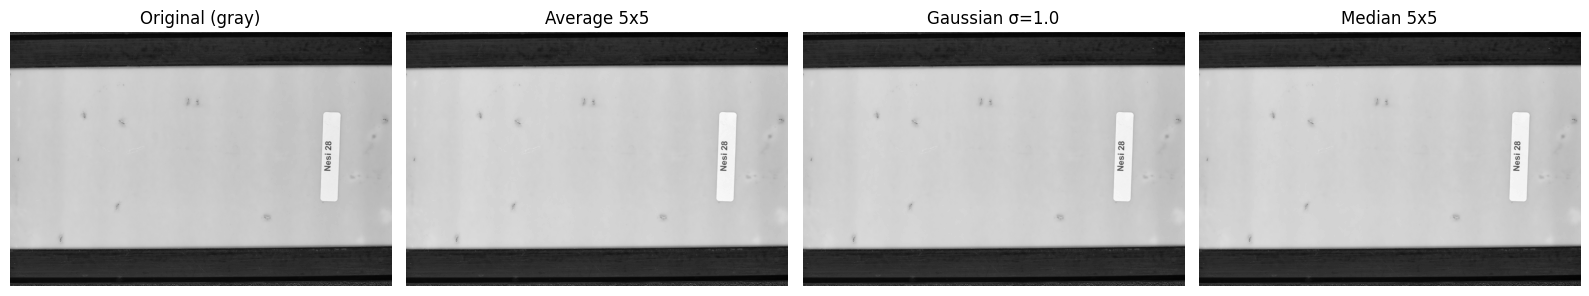

In [3]:
# Local filters on padded gray
KERNEL_SIZE = 5
SIGMA = 1.0
pad = KERNEL_SIZE // 2

padded = np.pad(gray, pad, mode="edge")

avg_filtered = np.zeros_like(gray)
for i in range(H):
    for j in range(W):
        window = padded[i:i + KERNEL_SIZE, j:j + KERNEL_SIZE]
        avg_filtered[i, j] = np.mean(window)

ax = np.arange(-pad, pad + 1)
xx, yy = np.meshgrid(ax, ax)
gauss_kernel = np.exp(-(xx**2 + yy**2) / (2 * SIGMA**2))
gauss_kernel = gauss_kernel / gauss_kernel.sum()

gauss_filtered = np.zeros_like(gray)
for i in range(H):
    for j in range(W):
        window = padded[i:i + KERNEL_SIZE, j:j + KERNEL_SIZE]
        gauss_filtered[i, j] = np.sum(window * gauss_kernel)

median_filtered = np.zeros_like(gray)
for i in range(H):
    for j in range(W):
        window = padded[i:i + KERNEL_SIZE, j:j + KERNEL_SIZE]
        median_filtered[i, j] = np.median(window)

# Before / after
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(gray, cmap="gray");            axes[0].set_title("Original (gray)")
axes[1].imshow(avg_filtered, cmap="gray");    axes[1].set_title(f"Average {KERNEL_SIZE}x{KERNEL_SIZE}")
axes[2].imshow(gauss_filtered, cmap="gray");  axes[2].set_title(f"Gaussian σ={SIGMA}")
axes[3].imshow(median_filtered, cmap="gray"); axes[3].set_title(f"Median {KERNEL_SIZE}x{KERNEL_SIZE}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Otsu threshold (0-255): 117  →  normalized: 0.4588


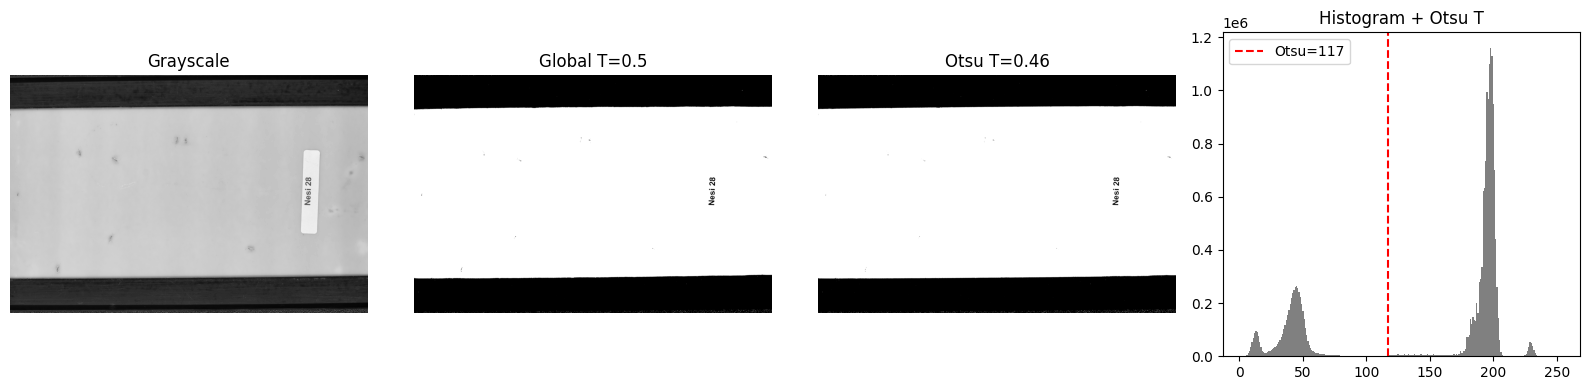

In [4]:
# Fixed threshold vs Otsu
GLOBAL_T = 0.5
OTSU_BINS = 256

binary_global = (gray > GLOBAL_T).astype(np.float64)

gray_uint8 = (gray * 255).astype(np.uint8)

hist = np.zeros(OTSU_BINS, dtype=np.int64)
for i in range(H):
    for j in range(W):
        hist[gray_uint8[i, j]] += 1

total_pixels = H * W
best_t = 0
best_variance = 0.0

for t in range(OTSU_BINS):
    w0 = np.sum(hist[:t + 1])
    w1 = total_pixels - w0

    if w0 == 0 or w1 == 0:
        continue

    mean0 = np.sum(np.arange(t + 1) * hist[:t + 1]) / w0
    mean1 = np.sum(np.arange(t + 1, OTSU_BINS) * hist[t + 1:]) / w1

    variance = w0 * w1 * (mean0 - mean1) ** 2

    if variance > best_variance:
        best_variance = variance
        best_t = t

otsu_threshold = best_t / 255.0
binary_otsu = (gray > otsu_threshold).astype(np.float64)

print(f"Otsu threshold (0-255): {best_t}  →  normalized: {otsu_threshold:.4f}")

# Masks and histogram
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")

axes[1].imshow(binary_global, cmap="gray")
axes[1].set_title(f"Global T={GLOBAL_T}")

axes[2].imshow(binary_otsu, cmap="gray")
axes[2].set_title(f"Otsu T={otsu_threshold:.2f}")

axes[3].bar(range(OTSU_BINS), hist, color="gray", width=1)
axes[3].axvline(best_t, color="red", linestyle="--", label=f"Otsu={best_t}")
axes[3].set_title("Histogram + Otsu T")
axes[3].legend()

for ax in axes[:3]:
    ax.axis("off")

plt.tight_layout()
plt.show()

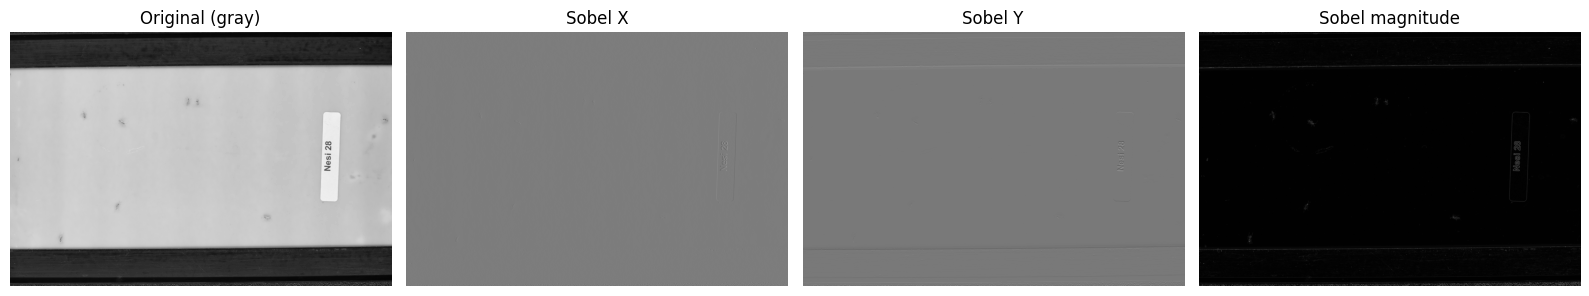

In [5]:
# Sobel edge detection (convolution on padded gray)
SOBEL_SIZE = 3
sobel_pad = SOBEL_SIZE // 2

sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=np.float64)

sobel_y_kernel = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1],
], dtype=np.float64)

padded_sobel = np.pad(gray, sobel_pad, mode="edge")

sobel_gx = np.zeros_like(gray)
sobel_gy = np.zeros_like(gray)
for i in range(H):
    for j in range(W):
        window = padded_sobel[i:i + SOBEL_SIZE, j:j + SOBEL_SIZE]
        sobel_gx[i, j] = np.sum(window * sobel_x_kernel)
        sobel_gy[i, j] = np.sum(window * sobel_y_kernel)

sobel_magnitude = np.sqrt(sobel_gx**2 + sobel_gy**2)

def norm_for_display(arr):
    arr_min, arr_max = arr.min(), arr.max()
    if arr_max == arr_min:
        return np.zeros_like(arr)
    return (arr - arr_min) / (arr_max - arr_min)

gx_show = norm_for_display(sobel_gx)
gy_show = norm_for_display(sobel_gy)
mag_show = norm_for_display(sobel_magnitude)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original (gray)")

axes[1].imshow(gx_show, cmap="gray")
axes[1].set_title("Sobel X")

axes[2].imshow(gy_show, cmap="gray")
axes[2].set_title("Sobel Y")

axes[3].imshow(mag_show, cmap="gray")
axes[3].set_title("Sobel magnitude")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()